In [10]:
import refnx
import numpy as np

from hogben.models.base import MagneticSLD
from hogben.models.samples import Sample
from hogben.optimise import Optimiser, optimise_parameters
from hogben.utils import Fisher
from hogben.visualise import angle_choice

from refnx.dataset import ReflectDataset
from refnx.analysis import Objective, GlobalObjective, Parameter, CurveFitter
from refnx.reflect import SLD, ReflectModel, MixedReflectModel, Slab, Structure

import os.path

# Reduce size of plots for the notebook.
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7,5)
plt.rcParams['figure.dpi'] = 100

In [27]:
def protein_structure(ref_layer=False):
    # Slab thicknesses
    t_SiO2 = Parameter(15, 'SiO2 thickness', (0, 60))
    t_inner_hg = Parameter(15, 'Inner headgroup thickness', (10, 30))
    t_tg = Parameter(28, 'Total tailgroup thickness', (20, 40))
    t_outer_hg = Parameter(18, 'Outer headgroup thickness', (10, 30))
    t_extra = Parameter(60, 'Extramembrane domain thickness', (10, 35))

    # Volume fractions and volumes
    phi_s = Parameter(0.36, 'Volume fraction of solvent', (0, 1))
    phi_extra = Parameter(0.345, 'Volume fraction of protein in extra domain', (0, 1))
    phi_innerhg = Parameter(0.47, 'Volume fraction solvent inner hg', (0.3, 0.7))
    phi_outerhg = Parameter(0.83, 'Volume fraction solvent outer hg', (0.0, 1))
    V_TMD = Parameter(0.245, 'TMD Molecular volume', (0, 0.6))
    V_extra = Parameter(0.245, 'Extra membrane Molecular volume', (0, 0.6))
    phi_tmd = phi_extra * (t_extra*V_TMD)/(t_tg*V_extra) #Important constraint to make the protein in tails and outside membrane same

    # SLD Values
    sld_TMD = Parameter(0.5, 'TMD Protein SLD', (0, 25))
    sld_lipacyl = Parameter(-0.3, 'Lipid acyl chains tg SLD', (-1, 1)) # not the exact same representation as the paper, but correct value
    sld_acyl = phi_tmd*sld_TMD + (1-phi_tmd)*sld_lipacyl
    sld_innerhg = Parameter(3, 'SLD inner hg', (1, 5))
    sld_outerhg = Parameter(3, 'SLD outer hg', (1, 5))
    sld_extra_h = Parameter(1.8, 'SLD extramembrane in H2O', (0, 5))
    sld_extra_d = Parameter(2.9, 'SLD extramembrane in D2O', (0, 5))
    sld_extra_smw = Parameter(2.2, 'SLD extramembrane in SMW', (0, 5))
    sld_sio2 = Parameter(3.5, 'SLD sio2', (0, 10))
    sld_h2o = Parameter(-0.45, 'Contrast 1', (-0.56, 6.14))
    sld_smw = Parameter(2.07, 'Contrast 2', (-0.56, 6.14))
    sld_d2o = Parameter(6.14, 'Contrast 3', (-0.56, 6.14))

    # Roughness
    r_SiO2 = Parameter(3, 'SiO2 roughness', (0, 15))
    r_inner_hg = Parameter(3, 'Inner headgroup roughness', (1, 5))
    r_tg = Parameter(3, 'Total tailgroup roughness', (1, 5))
    r_outer_hg = Parameter(3, 'Outer headgroup roughness', (1, 5))
    r_extra = Parameter(3, 'Extramembrane domain roughness', (1, 5))
    

    # Define slabs
    sub = refnx.reflect.SLD(2.074)
    SiO2 = refnx.reflect.SLD(sld_sio2, name="SiO2")(t_SiO2, r_SiO2, vfsolv=0.35)

    inner_hg = refnx.reflect.SLD(sld_innerhg, name="Inner Head Group")(t_inner_hg, r_inner_hg, vfsolv=phi_innerhg)

    # tail = refnx.reflect.SLD(sld_acyl, name="Tail groups")(t_tg, r_tg, vfsolv=phi_s)
    tail = refnx.reflect.SLD(sld_acyl, name="Tail group")(t_tg, r_tg, vfsolv=phi_s)

    outer_hg = refnx.reflect.SLD(sld_outerhg, name = "Outer head group")(t_outer_hg, r_outer_hg, vfsolv=phi_outerhg)
    extra_d = refnx.reflect.SLD(sld_extra_d, "Extra protein")(t_extra, r_extra, vfsolv=(1-phi_extra))
    extra_h = refnx.reflect.SLD(sld_extra_h, "Extra protein")(t_extra, r_extra, vfsolv=(1-phi_extra))
    extra_smw = refnx.reflect.SLD(sld_extra_smw, "Extra protein")(t_extra, r_extra, vfsolv=(1-phi_extra))

    # Define solvents
    H2O = refnx.reflect.SLD(sld_h2o, name="H2O solvent")(rough=2)
    D2O = refnx.reflect.SLD(sld_d2o, name="D2O solvent")(rough=2)

    # Choose varying parameters
    params = [
    # t_tg,
    # t_SiO2,
    t_extra,
    # t_outer_hg,
    # t_inner_hg,
    #        phi_innerhg,
    #        phi_outerhg,
    # phi_s,
    phi_extra,
        # r_tg,
        # r_inner_hg,
        # r_outer_hg,
    # sld_outerhg,
    # sld_lipacyl,
    # sld_innerhg,
    #     sld_extra_d,
    #    sld_extra_smw,
    #       sld_extra_h
    ]

    for param in params:
        param.vary = True
    
    # Define reference layer
    ul_thick = Parameter(50, 'Underlayer Thickness', (1e-7, 250))
    ul_nsld = Parameter(5, 'Underlayer Nuclear SLD', (0.5, 8))
    ul_msld = Parameter(2.7, 'Underlayer Magnetic SLD', (1e-7, 6))
    ul_thick.optimize = True
    ul_nsld.optimize = True
    ul_msld.optimize = True
    
    # Magnetic reference layer
    ul_slab = MagneticSLD(SLDn=ul_nsld, SLDm=ul_msld)(thick=ul_thick, rough=2)

    if ref_layer:
        # With reference layer      
        SiO2 = refnx.reflect.SLD(sld_sio2, name="SiO2")(t_SiO2, r_SiO2, vfsolv=0.0) # no solvent in SiO2 if not top facing layer
        structure_d2o = sub | SiO2 | ul_slab | inner_hg | tail | outer_hg | extra_d | D2O
        structure_h2o = sub | SiO2 | ul_slab | inner_hg | tail | outer_hg | extra_h | H2O        
        
    else:
        SiO2 = refnx.reflect.SLD(sld_sio2, name="SiO2")(t_SiO2, r_SiO2, vfsolv=0.35)
        structure_d2o = sub | SiO2 | inner_hg | tail | outer_hg | extra_d | D2O
        structure_h2o = sub | SiO2 | inner_hg | tail | outer_hg | extra_h | H2O        
        
    


    structures = [
                structure_d2o,
                structure_h2o,
                ]
    return structures

In [28]:
pth = './'
data_protein_d = ReflectDataset(os.path.join(pth, '18APC_CorA_D2O.dat'))
data_protein_h = ReflectDataset(os.path.join(pth, '18APC_CorA_H2O.dat'))

objective_h = Objective(ReflectModel(protein_structure(ref_layer=False)[1], bkg=0.5e-5, dq=6), data_protein_h)
objective_d = Objective(ReflectModel(protein_structure(ref_layer=False)[0], bkg=0.3e-5, dq=6), data_protein_d)
global_objective = GlobalObjective([objective_h, objective_d])

In [29]:
fitter = CurveFitter(global_objective)

In [15]:
result = fitter.fit('differential_evolution')

-16.515503698379007: : 843it [05:20,  2.63it/s] 


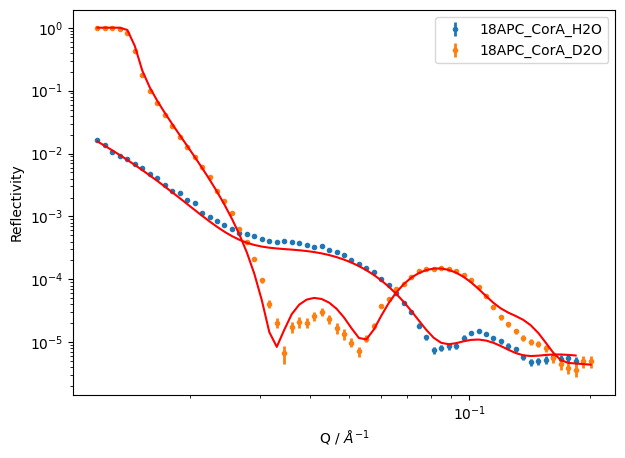

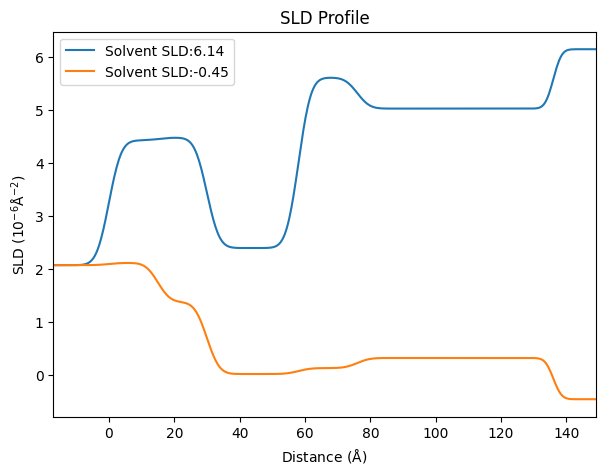

In [4]:
global_objective.plot()
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Q / $\AA^{-1}$')
plt.ylabel('Reflectivity')
plt.legend();

new_sample = Sample(protein_structure(ref_layer=False))
new_sample.sld_profile("")

# Define samples

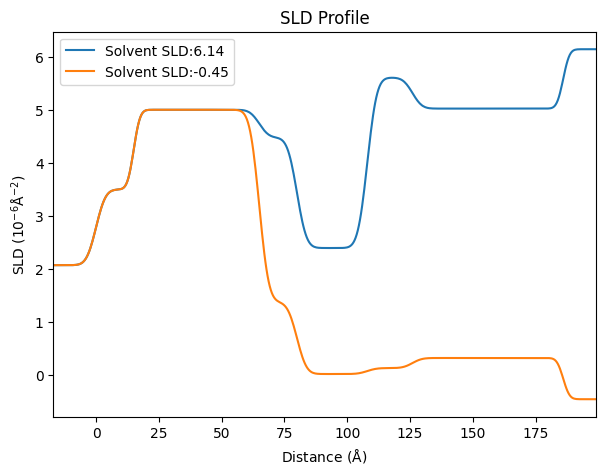

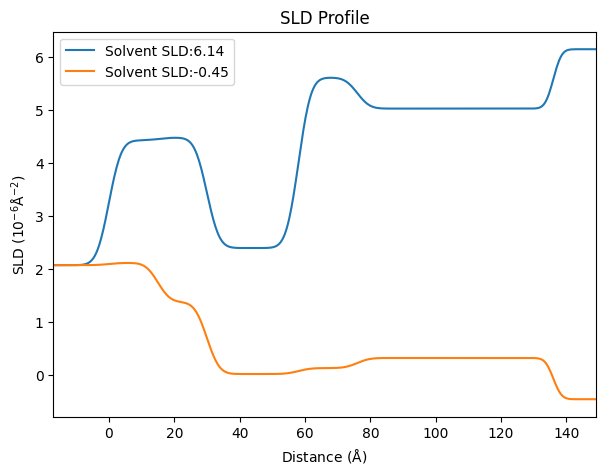

In [31]:
new_sample_ref = Sample(protein_structure(ref_layer=True))
new_sample_ref.polarised = False # Set to false to make it nuclear ref layer
new_sample_ref.sld_profile("test")

new_sample = Sample(protein_structure(ref_layer=False))
new_sample.sld_profile("")


# Optimise reference layer

The parameters with the highest information could be found at:
Underlayer Thickness: 195
Underlayer Nuclear SLD: 7.98
-----------------------------------------------------------------
The minimum eigenvalue of the Fisher Information before optimization: 0.0572
The minimum eigenvalue of the Fisher Information after optimization: 0.0677
The information content is 1.18 times as large after optimization.


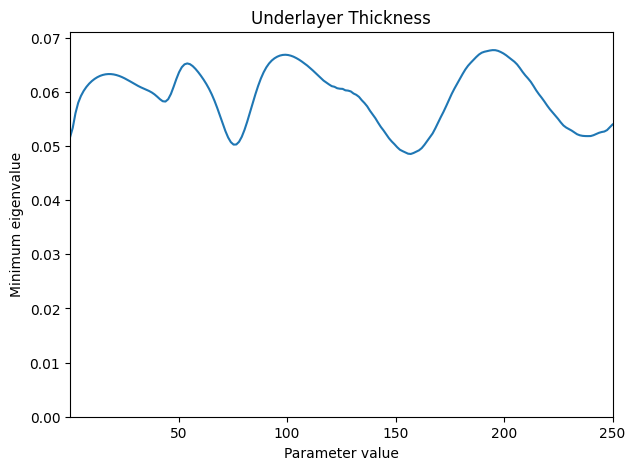

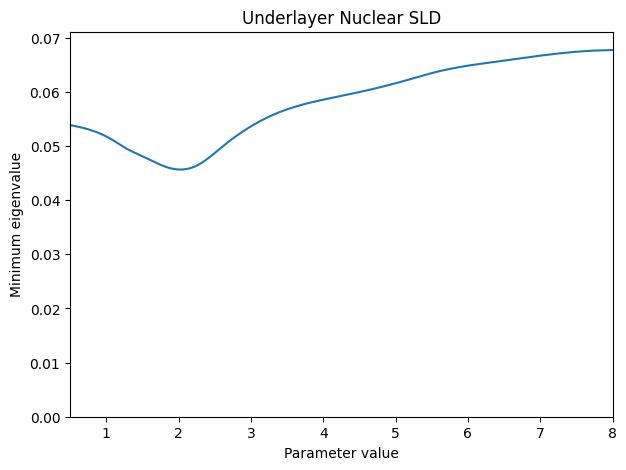

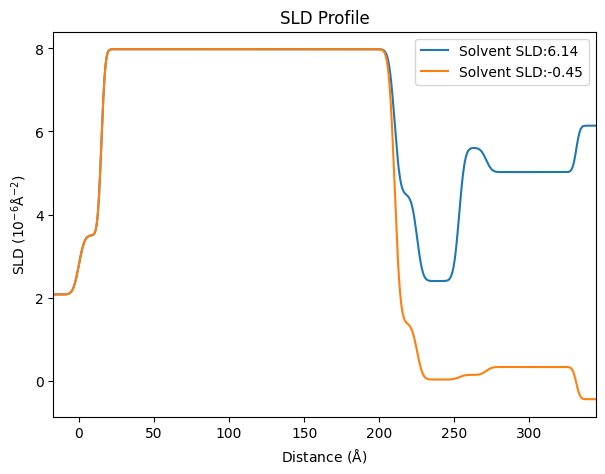

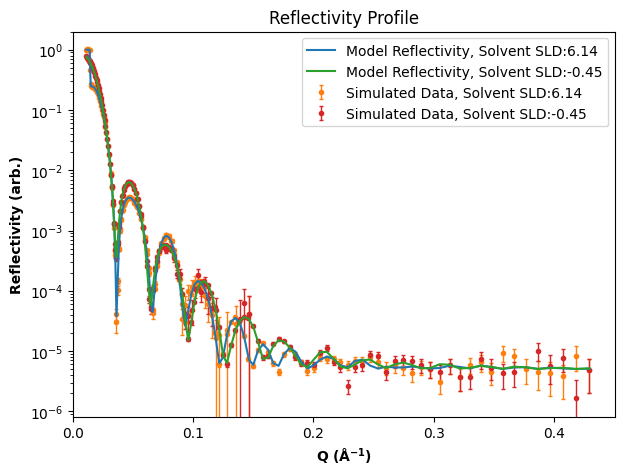

In [32]:
angle_times = [(0.7, 100, 25), (2.0, 100, 75)]
optimise_parameters(new_sample_ref, angle_times)

# Optimise angle_times

In [33]:
optimiser = Optimiser(new_sample_ref)
num_angles = 2 # Number of angles to optimise.

# Find the optimal angles and times using differential evolution.
angles, splits, _ = optimiser.optimise_angle_times(num_angles, angle_bounds=(0.2, 4.0), verbose=False)

# Calculate the counting times from the splits using total counting time of 100.
times = np.array(splits) * 100

print('Angles: {}'.format(np.round(angles, 2)))
print('Times: {}'.format(np.round(times, 1)))

Angles: [1.17 1.36]
Times: [  0. 100.]


# Get improvement compared to unoptimised (no ref. layer, unoptimal angle_times)

In [37]:
angle_times_optimised = [(angles[0], 100, times[0]), (angles[1], 100, times[1])]
fisher_optimised = Fisher.from_sample(new_sample_ref, angle_times_optimised)
print(fisher_optimised.min_eigenval)

angle_times_unoptimised = [(0.7, 100, 25), (2.0, 100, 75)]
fisher_unoptimised = Fisher.from_sample(new_sample, angle_times_unoptimised)
print(fisher_unoptimised.min_eigenval)
improvement = fisher_optimised.min_eigenval/fisher_unoptimised.min_eigenval
print(f'Optimising gave an improvement of a factor {round(improvement,2)}')

0.08087306609615151
0.05059885664584692
Optimising gave an improvement of a factor 1.6


In [ ]:
pth = './'
data_protein_d = ReflectDataset(os.path.join(pth, '18APC_CorA_D2O.dat'))
data_protein_h = ReflectDataset(os.path.join(pth, '18APC_CorA_H2O.dat'))

objective_h = Objective(ReflectModel(protein_structure(ref_layer=False)[1], bkg=0.5e-5, dq=6), data_protein_h)
objective_d = Objective(ReflectModel(protein_structure(ref_layer=False)[0], bkg=0.3e-5, dq=6), data_protein_d)
global_objective = GlobalObjective([objective_h, objective_d])
new_sample_ref.structures

[Structure(components=[Slab(Parameter(value=0.0, name=' - thick', vary=False, bounds=Interval(lb=-np.inf, ub=np.inf), constraint=None), SLD([Parameter(value=2.074, name=' - sld', vary=False, bounds=Interval(lb=-np.inf, ub=np.inf), constraint=None), Parameter(value=0.0, name=' - isld', vary=False, bounds=Interval(lb=-np.inf, ub=np.inf), constraint=None)], name=''), Parameter(value=0.0, name=' - rough', vary=False, bounds=Interval(lb=-np.inf, ub=np.inf), constraint=None), name='', vfsolv=Parameter(value=0.0, name=' - volfrac solvent', vary=False, bounds=Interval(lb=0.0, ub=1.0), constraint=None), interface=None), Slab(Parameter(value=15.0, name='SiO2 thickness', vary=False, bounds=Interval(lb=0.0, ub=60.0), constraint=None), SLD([Parameter(value=3.5, name='SLD sio2', vary=False, bounds=Interval(lb=0.0, ub=10.0), constraint=None), Parameter(value=0.0, name='SiO2 - isld', vary=False, bounds=Interval(lb=-np.inf, ub=np.inf), constraint=None)], name='SiO2'), Parameter(value=3.0, name='SiO2 ro

# Visualising

>>> 0/50
First angle choice: 1.36


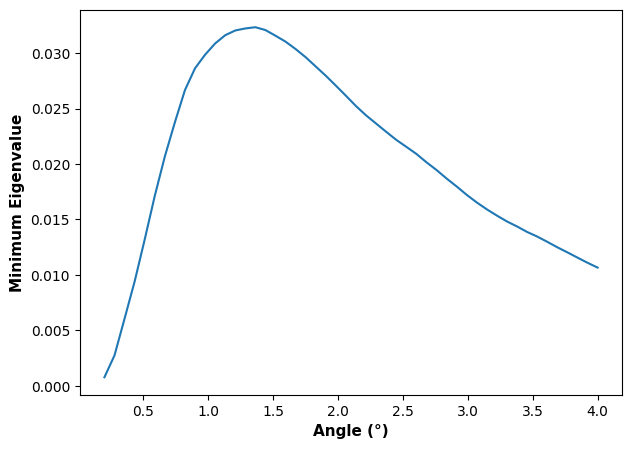

In [35]:
# Path to directory to save results to.
save_path = '../examples/results'

# Number of data points to simulate.
points = 150

# Time to use for simulation.
# A time of 1 approximately corresponds to 1.5 minutes.
time = 40

# Angles (in degrees) to consider.
angle_range = np.linspace(0.2, 4.0, 50)
initial_angle_times = [] # No angles measured so far.
angle_1 = angle_choice(new_sample_ref, initial_angle_times, angle_range, points, time, save_path, 'angle_choice_1')
print('First angle choice: {}'.format(round(angle_1, 2)))


>>> 0/50
Second angle choice: 1.36


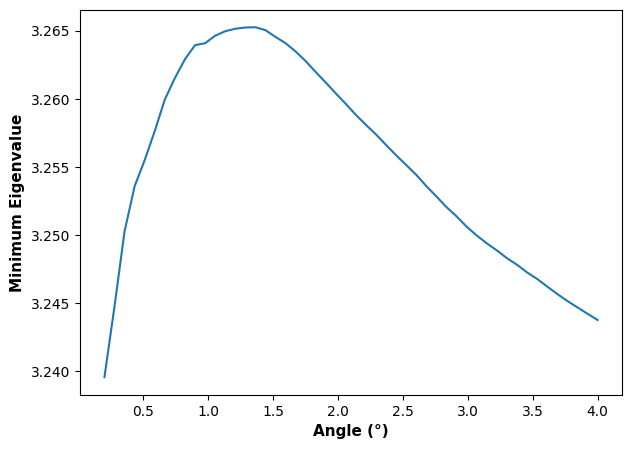

In [36]:
x = 100 # Change x to adjust the counting time.
initial_angle_times = [(angle_1, points, time*x)] # (Angle, Points, Time)
angle_2 = angle_choice(new_sample_ref, initial_angle_times, angle_range, points, time, save_path, 'angle_choice_2')
print('Second angle choice: {}'.format(round(angle_2, 2)))